# Pandas Practice: The Iris Dataset

In this notebook you will independently apply everything from `01_Introduction_to_Pandas.ipynb` and `03_Introduction_to_Visualization.ipynb` to a new dataset. The **Iris dataset** is one of the most widely used datasets in data science — it contains measurements (in centimetres) of 150 iris flowers across three species. Your goal is to load it, explore it, answer questions with code, and visualise your findings.

---

![Iris species](../images/iris.png)

---

In [13]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Part 1 — Exploring the Data

### Challenge 1: Preview and inspect

Display the first 5 rows and the last 10 rows of the DataFrame.

In [15]:
df.tail(5)
#df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


### Challenge 2: How many irises are in the dataset?

How many rows and columns does the DataFrame have?

In [ ]:
df.info()  #150 rows and 5 columns

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


### Challenge 3: How many species are there?

Find out how many distinct species exist in the dataset, and what they are called.

In [8]:
df['species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

---

## Part 2 — Statistics

### Challenge 4: Descriptive statistics for petal length

Calculate the mean, median, and mode for `petal_length`. What can you conclude about the distribution?

In [ ]:
#df['petal_length'].describe()

petal_mean = df['petal_length'].mean()
petal_median = df['petal_length'].median()
petal_mode = df['petal_length'].mode()
print("Mean:", petal_mean.round(2))
print("Median:", petal_median)
print("Mode:", petal_mode)

# The distribution is not uniform. It is skewed because the mean is bigger than the mode and the median is bigger
# than the mean.

Mean: 3.76
Median: 4.35
Mode: 0    1.5
Name: petal_length, dtype: float64


### Challenge 5: Range and spread

What is the smallest and largest value for `petal_length`? Calculate the variance and standard deviation.

In [ ]:
petal_variance = df['petal_length'].var()
petal_std = df['petal_length'].std()
petal_min = df['petal_length'].min()
petal_max = df['petal_length'].max()
print("Standard deviation:", petal_std.round(2))
print("Variance:", petal_variance.round(2))
print("Minimum:", petal_min)
print("Maximum:", petal_max)

Standard Deviation: 1.76
Variance: 3.11
Minimum: 1.0
Maximum: 6.9


### Challenge 6: Full summary

Use a single command to get the basic descriptive statistics for all columns.

In [30]:
df['petal_length'].describe()

count    150.000000
mean       3.758667
std        1.764420
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length, dtype: float64

### Challenge 7: Overall average sepal length

What is the average `sepal_length` across all 150 flowers?

In [32]:
df['sepal_length'].mean().round(2)


np.float64(5.84)

---

## Part 3 — Groupby

### Challenge 8: Count by species

Use `groupby` to count the number of observations for each species.

In [35]:
#df.groupby('species')['petal_length'].count()
df.groupby('species').size()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

### Challenge 9: Average measurements by species

Use `groupby` to find the average `sepal_length`, `sepal_width`, `petal_length`, and `petal_width` for each species.

In [39]:
iris_group = df.groupby('species')
print("Sepal length:", iris_group['sepal_length'].mean().round(2))
print("Sepal width:", iris_group['sepal_width'].mean().round(2))
print("Petal length:", iris_group['petal_length'].mean().round(2))
print("Petal width:", iris_group['petal_width'].mean().round(2))

df.groupby('species')[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].mean().round(2)

Sepal length: species
Iris-setosa        5.01
Iris-versicolor    5.94
Iris-virginica     6.59
Name: sepal_length, dtype: float64
Sepal width: species
Iris-setosa        3.42
Iris-versicolor    2.77
Iris-virginica     2.97
Name: sepal_width, dtype: float64
Petal length: species
Iris-setosa        1.46
Iris-versicolor    4.26
Iris-virginica     5.55
Name: petal_length, dtype: float64
Petal width: species
Iris-setosa        0.24
Iris-versicolor    1.33
Iris-virginica     2.03
Name: petal_width, dtype: float64


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.01,3.42,1.46,0.24
Iris-versicolor,5.94,2.77,4.26,1.33
Iris-virginica,6.59,2.97,5.55,2.03


---

## Part 4 — Column Operations and Filtering

### Challenge 10: Add a new column

Create a new column `sepal_total` that is the sum of `sepal_width` and `sepal_length`.

In [ ]:
df = df.eval('`sepal_total` = `sepal_width` + `sepal_length`')
#df = df.assign(sepal_total=df['sepal_width'] + df['sepal_length'])
df.columns
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6


### Challenge 11: Add petal area

Create a new column `petal_area` as a rough estimate of petal area: `petal_length × petal_width`.

In [8]:
df = df.eval('`petal_area` = `petal_length` * `petal_width`')
#df = df.assign(sepal_total=df['sepal_width'] + df['sepal_length'])
df.columns
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28


### Challenge 12: Filter by petal area

Create a new DataFrame containing only the flowers where `petal_area` is greater than 1 cm².

In [10]:
df1 = df.query('petal_area > 1.0')
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90


### Challenge 13: Split by species

Create three separate DataFrames — one for each species — using the full dataset.

In [21]:
df['species'].unique()

dfs1 = df[df['species'] == df['species'].unique()[0]]
dfs1.head()
dfs2 = df[df['species'] == df['species'].unique()[1]]
dfs2.head()
dfs3 = df[df['species'] == df['species'].unique()[2]]
dfs3.head()

,sepal_length,sepal_width,petal_length,petal_width,species
100,6.3,3.3,6.0,2.5,Iris-virginica
101,5.8,2.7,5.1,1.9,Iris-virginica
102,7.1,3.0,5.9,2.1,Iris-virginica
103,6.3,2.9,5.6,1.8,Iris-virginica
104,6.5,3.0,5.8,2.2,Iris-virginica


---

## Part 5 — Visualisation

### Challenge 14: Histogram of petal length

Create a histogram of `petal_length`. Describe the distribution — is it symmetric, skewed, or does it appear to have multiple peaks?

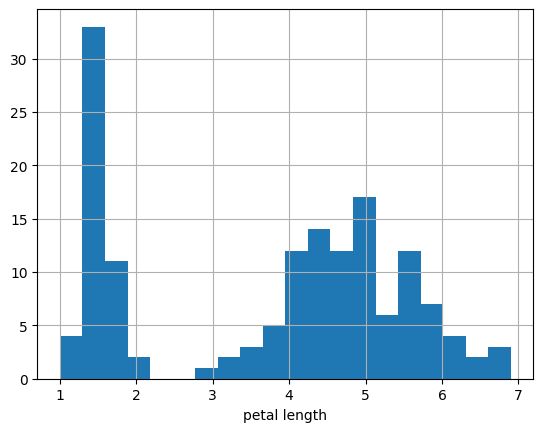

count    150.000000
mean       3.758667
std        1.764420
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length, dtype: float64

In [ ]:
df.head()

#df['petal_length'].plot(kind='hist', title='Distribution of petal length')
df['petal_length'].hist(bins=20)
plt.xlabel('petal length')
plt.show()

df['petal_length'].describe()
#The distribution is asymmetric, skewed, and have multiple peaks. 
# It is skewed because mixes the distribution of three classes in one distribution.

### Challenge 15: Scatter matrix of petal dimensions

Create a scatter plot of `petal_length` vs `petal_width`. Do larger petals tend to be longer as well?

> Bonus: use `pd.plotting.scatter_matrix(df)` to see all pairwise relationships at once.

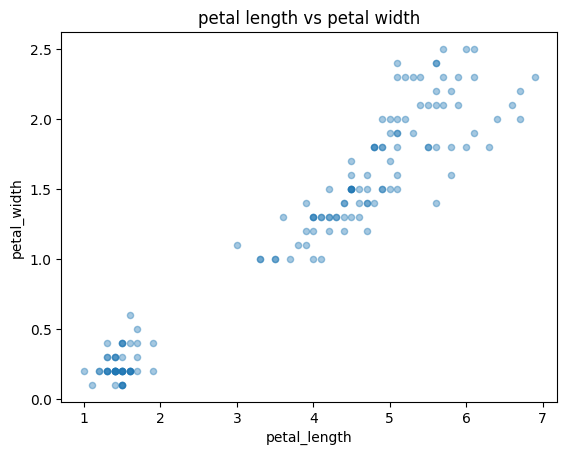

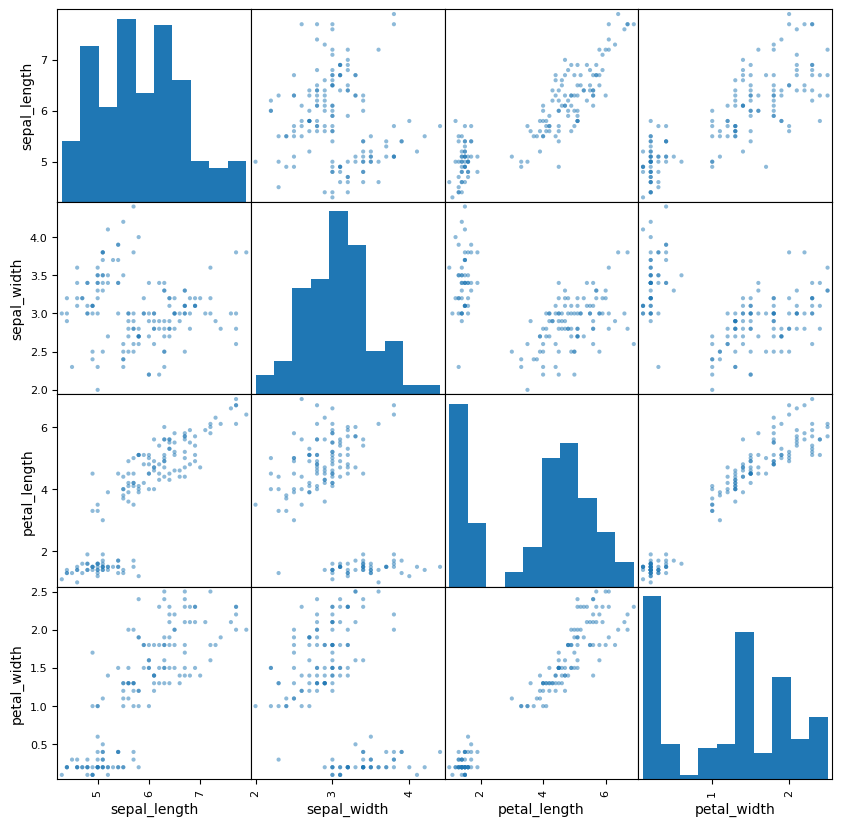

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [41]:
df.plot(kind='scatter', x='petal_length', y='petal_width',
        title='petal length vs petal width', alpha=0.4)

# Larger petals tend to be longer: strong positive correlation

pd.plotting.scatter_matrix(df, figsize=(10, 10))
plt.show()

# sepal features overlap more. There is a strong corelation between petal length and sepal length

df.columns
df.dtypes #species feature is str so it is not included in the graph
